In [1]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Modelo lineal

En el modelo lineal el valor que toma una variable $Y$ (target) se predice como una combinación lineal de un conjunto de variables predictoras $X_i$.

\begin{align}
  \hat{y}_i = w_0 + w_1\cdot x_{i1} + w_2 \cdot x_{i2} + ... + w_m \cdot x_{im}
\end{align}


Como todo modelo paramétrico de aprendizaje, debe ser entrenado para poder definir sus parámetros de modo de optimizar una métrica de performance (por ej. minimizar una medida del error).

Para el modelo lineal, la forma más difundida es por **cuadrados mínimos**. Se busca minimizar la suma de los cuadrados de los residuos. Los residuos son las diferencias entre los valores reales y predichos $(y - \hat{y})$.

Veamos un ejemplo en dos dimensiones (una viarble predictora $X$ y una variable target $Y$). La solución en este caso va a estar dada por la recta que mejor ajuste $(w_0 + w_1 \cdot x_1)$. En un caso con dos variables predictoras $X_1$ y $X_2$, la solución va a estar dada por un plano.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
data = {
    'x': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'y': [19.48, 18.31, 24.24, 30.62, 23.83, 25.83, 36.9, 34.84, 30.65, 37.71, 34.68, 36.67, 42.21, 33.43, 36.38, 44.19, 43.94, 52.57, 48.46, 47.94]
}

df = pd.DataFrame(data)
print(df)


     x      y
0    1  19.48
1    2  18.31
2    3  24.24
3    4  30.62
4    5  23.83
5    6  25.83
6    7  36.90
7    8  34.84
8    9  30.65
9   10  37.71
10  11  34.68
11  12  36.67
12  13  42.21
13  14  33.43
14  15  36.38
15  16  44.19
16  17  43.94
17  18  52.57
18  19  48.46
19  20  47.94


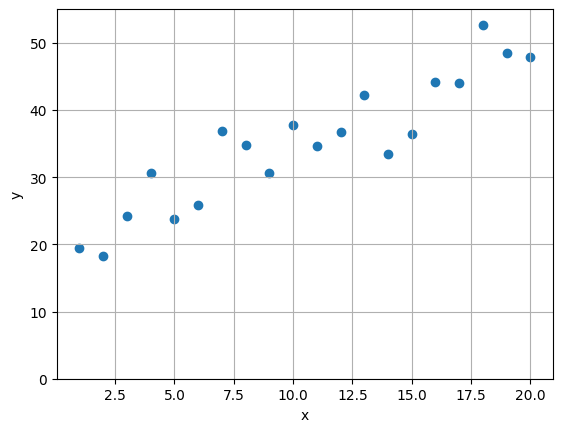

In [14]:
plt.scatter(df.x, df.y)
plt.ylabel('y')
plt.xlabel('x')
plt.ylim(0,55)
plt.grid()

In [15]:
# Conjunto de parámetros 1: w0 = 25, w1 = 0.8
w0 = 25
w1 = 0.8
df['y_pred_1'] = w0 + w1 * df.x

Suma de los cuadrados de los residuos: 661.79


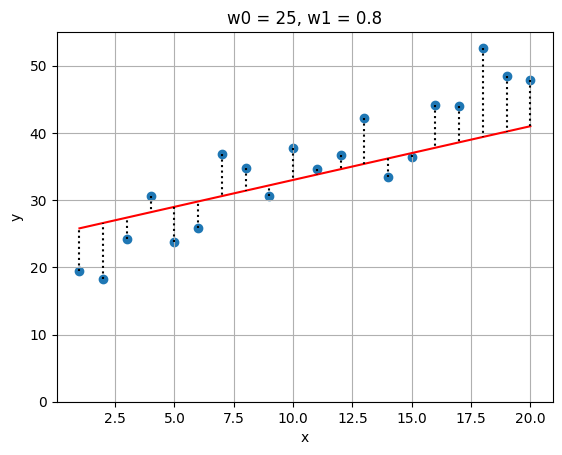

In [16]:
plt.scatter(df.x, df.y)
plt.ylabel('y')
plt.xlabel('x')
plt.ylim(0,55)
plt.grid()
plt.plot(df.x, df.y_pred_1, color='red', label='y_pred_1')
plt.title(f"w0 = {w0}, w1 = {w1}")

# Graficar los residuos con líneas punteadas
suma_cuadrados = 0
for i in range(len(df)):
    plt.plot([df['x'][i], df['x'][i]], [df['y'][i], df['y_pred_1'][i]], 'k:')
    suma_cuadrados += (df['y'][i] - df['y_pred_1'][i])**2

print(f'Suma de los cuadrados de los residuos: {suma_cuadrados:.2f}')

In [17]:
# Entrenamos el modelo
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(df[['x']], df[['y']])
intercept = reg.intercept_
coeficientes  = reg.coef_


print(f'Coeficientes: {coeficientes}')
print(f'Intercept: {intercept}')

Coeficientes: [[1.50218045]]
Intercept: [19.37110526]


Suma de los cuadrados de los residuos: 273.08


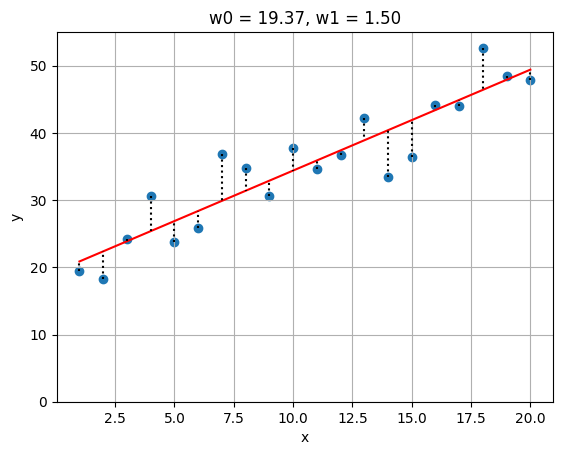

In [18]:
# Conjunto de parámetros 2: w0 = 19.37, w1 = 1.5
w0 = intercept[0]
w1 = coeficientes[0][0]
df['y_pred_2'] = w0 + w1 * df.x

plt.scatter(df.x, df.y)
plt.ylabel('y')
plt.xlabel('x')
plt.ylim(0,55)
plt.grid()
plt.plot(df.x, df.y_pred_2, color='red', label='y_pred_2')
plt.title(f"w0 = {w0:.2f}, w1 = {w1:.2f}")

# Graficar los residuos con líneas punteadas
suma_cuadrados = 0
for i in range(len(df)):
    plt.plot([df['x'][i], df['x'][i]], [df['y'][i], df['y_pred_2'][i]], 'k:')
    suma_cuadrados += (df['y'][i] - df['y_pred_2'][i])**2

print(f'Suma de los cuadrados de los residuos: {suma_cuadrados:.2f}')

Se dice que el modelo es **lineal** porque es **lineal en sus parámetros**, es decir, los $w_i$ no aparecen como exponentes ni multiplicados ni divididos por otros parámetros. Pero no impide que puedan modelarse relaciones no lineales entre la variable $Y$ y las covariables $X_i$.

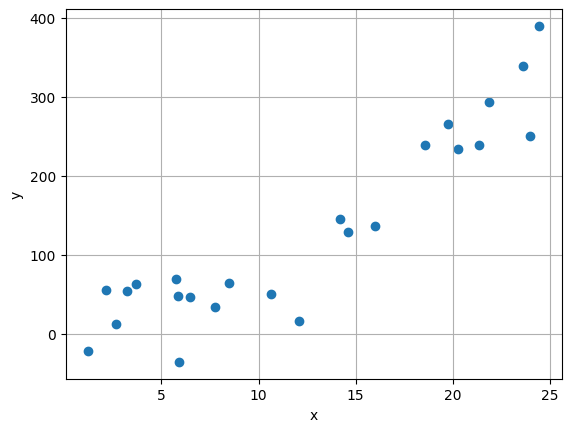

In [19]:
# Datos de ejemplo
data = {
    'x': [1.24, 2.14, 2.69, 3.22, 3.72, 5.78, 5.84, 5.89, 6.49, 7.75, 8.5, 10.62, 12.08, 14.18, 14.59, 15.99, 18.56, 19.72, 20.24, 21.33, 21.83, 23.6, 23.95, 24.43],
    'y': [-21.28, 56.23, 12.19, 55.08, 63.07, 69.96, 48.73, -35.29, 47.49, 33.62, 64.22, 50.69, 16.14, 146.01, 129.69, 136.81, 239.34, 266.13, 234.31, 238.74, 293.83, 339.39, 250.53, 389.87]
}

df = pd.DataFrame(data)


plt.scatter(df.x, df.y)
plt.ylabel('y')
plt.xlabel('x')
plt.grid()

Se ve una relación cuadrática entre X e Y. Podemos proponer entonces el siguiente modelo lineal:

\begin{align}
\hat{y_i} = w_0 + w_1 \cdot x_i + w_2 \cdot x^2_i
\end{align}

Con la notación de antes:
- $X_1$ es la variable $X$
- $X_2$ es la variable $X^2$

Este es un problema de aprendizaje supervisado, tenemos que definir la matriz $X$ de variables predictoras y el vector $y$ de la variable objetivo.

In [20]:
# Armado de la matriz X y el vector y:
X = np.column_stack((df.x, df.x**2))
print(X)
print(X.shape)

y = np.array(df.y)
print(y)
print(y.shape)

[[  1.24     1.5376]
 [  2.14     4.5796]
 [  2.69     7.2361]
 [  3.22    10.3684]
 [  3.72    13.8384]
 [  5.78    33.4084]
 [  5.84    34.1056]
 [  5.89    34.6921]
 [  6.49    42.1201]
 [  7.75    60.0625]
 [  8.5     72.25  ]
 [ 10.62   112.7844]
 [ 12.08   145.9264]
 [ 14.18   201.0724]
 [ 14.59   212.8681]
 [ 15.99   255.6801]
 [ 18.56   344.4736]
 [ 19.72   388.8784]
 [ 20.24   409.6576]
 [ 21.33   454.9689]
 [ 21.83   476.5489]
 [ 23.6    556.96  ]
 [ 23.95   573.6025]
 [ 24.43   596.8249]]
(24, 2)
[-21.28  56.23  12.19  55.08  63.07  69.96  48.73 -35.29  47.49  33.62
  64.22  50.69  16.14 146.01 129.69 136.81 239.34 266.13 234.31 238.74
 293.83 339.39 250.53 389.87]
(24,)


In [21]:
# Entrenamos el modelo
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X, y)
w0 = reg.intercept_
w1, w2 = reg.coef_


print(f'Coeficientes: {w1:0.2f}, {w2:0.2f}')
print(f'Intercept: {w0:0.2f}')

Coeficientes: -3.28, 0.67
Intercept: 29.73


In [22]:
# Creamos el vector de valores predichos de y. Hay dos formas:

# 1. Manualmente, a partir de los coeficientes obtenidos
df['y_pred'] = w0 + w1 * df['x'] + w2 * df['x']**2

# 2. Con el método predict
df['y_pred'] = reg.predict(X)

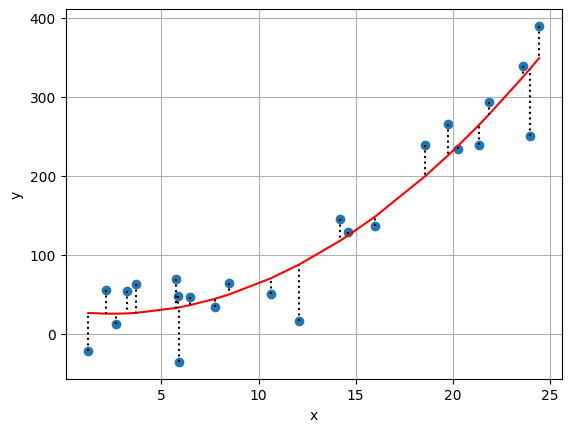

In [23]:
# Graficamos
plt.scatter(df.x, df.y)
plt.ylabel('y')
plt.xlabel('x')
plt.grid()
plt.plot(df.x, df.y_pred, color='red', label='y_pred')

# Graficar los residuos con líneas punteadas
for i in range(len(df)):
    plt.plot([df['x'][i], df['x'][i]], [df['y'][i], df['y_pred'][i]], 'k:')

Acá mostramos un ejemplo de regresión lineal múltiple (tenemos más de una covariable). Teníamos una sola variable predictora $(X)$ y generamos una nueva $(X^2)$. Si tenemos más de una variable predictora $(X_1, X_2, ..., X_m)$ también podemos generar nuevas variables a partir de la interacción entre ellas, por ejemplo creando una nueva variable igual a $X_1\cdot X_2$. Esto es parte de lo que llamamos anteriormente ingeniería de atributos (o *feature engineering*).

## Explicabilidad
Una ventaja por la cual el modelo lineal sigue utilizandose aún con la aparición de algoritmos muy potentes como las redes neuronales artificiales (RNA), es su **explicabilidad**.

Por ejemplo, si del ajuste de un conjunto de datos resulta que:

\begin{align}
\text{Calificaciones} = 50 + 5 \times \text{Horas_de_estudio} + 2 \times \text{Horas_de_sueño}
\end{align}

Podemos interpretar que:

- Intercepto ($w_0$ = 50.0):

El intercepto representa el valor esperado de las calificaciones cuando las horas de estudio y las horas de sueño son cero. En este caso, si un estudiante no estudia y no duerme (lo cual es una situación hipotética poco realista), la calificación esperada sería 50.

- Coeficiente de Horas_de_estudio ($w_1$ = 5.0):

Este coeficiente indica que por cada hora adicional de estudio, manteniendo constante el número de horas de sueño, se espera que las calificaciones aumenten en 5 puntos. Es decir, el estudio tiene un impacto positivo en las calificaciones.

- Coeficiente de Horas_de_sueño ($w_2$ = 2.0):

Este coeficiente indica que por cada hora adicional de sueño, manteniendo constante el número de horas de estudio, se espera que las calificaciones aumenten en 2 puntos. Esto sugiere que dormir más también tiene un efecto positivo, aunque menor, en las calificaciones.

### Variables categóricas

Se incorporan como **variables dummies**.


Nota:
- En los siguientes ejemplos los parámetros $\beta_i$ son los que indicabamos antes como $w_i$.
- La variable objetivo $Y$ es el saldo de la tarjeta de crédito (indicado como *balance*)


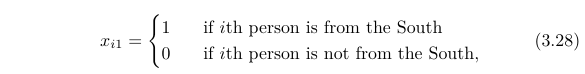

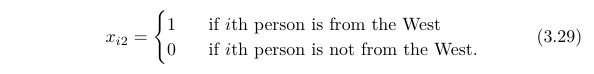

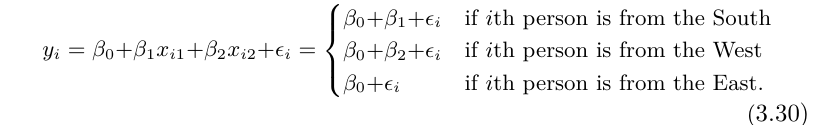

Puede interpretarse:
- $\beta_0$ como el *balance* promedio (valor esperado) para las personas del Este
- $\beta_1$ como la diferencia en el *balance* promedio entre las personas del Sur y las del Este
- $\beta_2$ como la diferencia en el *balance* promedio entre las personas del Oeste y las del Este.

### Interacción entre variables

$$
\text{balance}_i \approx \beta_0 + \beta_1 \cdot \text{income}_i + \beta_2 \cdot \text{student}_i + \beta_3 \cdot (\text{income}_i \times \text{student}_i)
$$

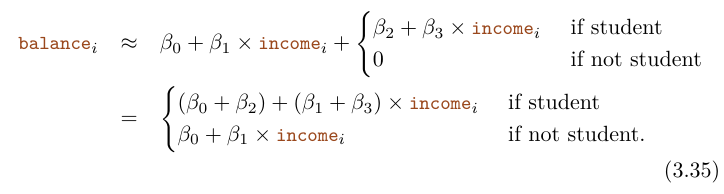

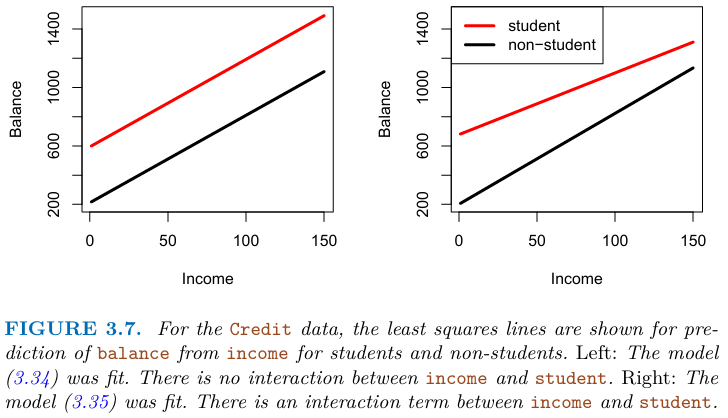

# Métricas para modelos de regresión

## Error cuadrático medio (MSE)

Mide el promedio de los errores al cuadrado entre los valores reales $(y)$ y las predicciones $(\hat{y})$. Penaliza fuertemente los errores grandes debido a la naturaleza cuadrática.
\begin{align}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{align}

## Raíz del error cuadrático medio (RMSE)
Es la raíz cuadrada del MSE. Proporciona una medida del error en las mismas unidades que la variable de salida.

\begin{align}
\text{RMSE} = \sqrt{\text{MSE}}
\end{align}


## Error absoluto medio (MAE)

Mide el promedio de los errores absolutos entre los valores reales y las predicciones. Es menos sensible a los errores grandes en comparación con el MSE.

\begin{align}
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\end{align}


## Coeficiente de determinación (R²)

Mide la **proporción de la varianza** en la variable dependiente que es **predecible a partir de las variables independientes**. Un $R^2$ cercano a 1 indica un buen ajuste del modelo.

\begin{align}
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
\end{align}

- En el modelo de regresión lineal simple (una sola covariable X), es el cuadrado del coeficiente de correlación de Pearson para la muestra $\{(x_i, y_i)\}_{1<=i<=n}$

- Es el cuadrado del coeficiente de correlación de Pearson para los pares $\{(y_i, \hat{y_i})\}_{1<=i<=n}$

## Coeficiente de determinación ajustado (R² ajustado)
El hecho de agregar variables explicativas $X_i$ al modelo de regresión sólo puede aumentar el R² en el conjunto de entrenamiento y nunca reducirlo (sean estas importantes o no). Es por eso que cuando se quieren comparar modelos de regresión con distinto número de covariables, se recomienda utilizar R² ajustado, que tiene en cuenta el número de covariables explicativas incluidas en el modelo.

\begin{align}
R_a^2 = 1 - \frac{n-1}{n-p-1}(1-R^2)
\end{align}

In [24]:
# Calculamos las métricas que vimos recién para el ejemplo del modelo lineal múltiple
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(df.y, df.y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(df.y, df.y_pred)
R2 = r2_score(df.y, df.y_pred)
n = len(df)
p = 2 # número de variables predictoras o covariables
R2_ajustado = 1 - (n-1) * (1-R2) / (n-p-1)

print(f'Error cuadrático medio (ECM o MSE): {mse:.2f}')
print(f'Raíz del error cuadrático medio (RECM o RMSE): {rmse:.2f}')
print(f'Error absoluto medio (MAE): {mae:.2f}')
print(f'R²: {R2:.3f}')
print(f'R² ajustado: {R2_ajustado:.3f}')

Error cuadrático medio (ECM o MSE): 1335.14
Raíz del error cuadrático medio (RECM o RMSE): 36.54
Error absoluto medio (MAE): 29.84
R²: 0.905
R² ajustado: 0.895


# Evaluación de un modelo

## Repaso división Train-Test

Para saber si un modelo es capaz de generalizar, se lo evalúa viendo su performance en datos que no fueron utilizados para su entrenamiento (conjunto de test).

Si el error de entrenamiento es bajo (es decir, si el modelo comete pocos errores en el conjunto de entrenamiento), pero el error en el conjunto de test es alto, eso significa que el modelo está **sobreajustando** los datos de entrenamiento.



## Validación cruzada *(cross-validation)*
Supongamos que tenemos un primer modelo de árbol de decisión, evaluamos su performance en test y vemos que está sobreajustando un poco, por lo que decidimos armar un nuevo modelo seteando una profundidad máxima *(max_depth)*. Evaluamos en test, y todavía parece que sobreajusta (error test >> error train). Decidimos entonces probar distintos valores de *max_depth* y además, distintos valores de *min_samples_leaf*, hasta conseguir un error en test aceptable.

El problema es que fuimos midiendo el error muchas veces en el conjunto de test y fuimos adaptando los hiperparámetros para producir el mejor modelo para **ese conjunto en particular**. Eso significa que es poco probable que el modelo tenga un buen rendimiento en datos nuevos. De nuevo caemos en el sobreajuste u *overfitting*.

¿Cómo hacemos entonces para comparar distintos modelos sin sobreajustar al conjunto de datos que separamos para test? Aplicamos **validación cruzada**.


La validación cruzada implica dividir el conjunto de datos en múltiples subconjuntos, entrenar el modelo en algunos de estos subconjuntos y validarlo en los subconjuntos restantes. Este proceso se repite varias veces, y los resultados se promedian para obtener una estimación más confiable de la performance del modelo. Se utiliza para optimizar hiperparámetros sin caer en el sobreajuste.

En especial vamos a ver la técnica de **k-fold cross-validation**.




## k-fold cross-validation

1. Dividir el conjunto de datos en $k$ partes (o "folds") aproximadamente del mismo tamaño.
2. Entrenar el modelo utilizando $k$ -1 folds y validar en el fold restante.
3. Repetir el proceso $k$ veces, cada vez con un fold diferente como conjunto de validación.
4. Promediar los resultados de las $k$ iteraciones para obtener la estimación final del rendimiento del modelo.

Se suele usar $k$ = 5.

<img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*z3OmZ2Vp3uskfgLIZVIeTQ.jpeg" width=300>


Siguientes pasos:

- El conjunto de hiperparámetros que optimice la métrica obtenida en **4.** se selecciona como el mejor.
- Se setea ese conjunto de hiperparámetros y se entrena el modelo utilizando todo el conjunto de entrenamiento original.
- Se evalúa, ahora sí, en el conjunto de test.


**Nota:** k-fold CV permite además tener una medida de la dispersión de la métrica de performance. Puedo ver si, por ejemplo, el RMSE en los k folds se mantiene aproximadamente constante o si varía mucho.

# Búsqueda de hiperparámetros


## Diferencia entre **parámetros** e **hiperparámetros** de un modelo

- Los **parámetros** son los valores internos del modelo que se aprenden automáticamente a partir de los datos durante el proceso de entrenamiento.

- Los **hiperparámetros** son configuraciones del modelo que deben establecerse antes del proceso de entrenamiento. No se aprenden a partir de los datos, sino que se eligen de antemano.

Por ejemplo, en árboles de decisión:
- Parámetros: Las características y los puntos de división (umbral) que se seleccionan en cada nodo interno del árbol.
- Hiperparámetros: rofundidad máxima (max_depth), número mínimo de muestras en una hoja (min_samples_leaf), criterio de división (impureza de Gini o *information gain*), etc.




## Algoritmos para la búsqueda de hiperparámetros

### Grid search

Grid search es una técnica sistemática para encontrar la combinación óptima de hiperparámetros. Esta técnica implica definir un conjunto discreto de valores posibles para cada hiperparámetro y evaluar todas las combinaciones posibles en una cuadrícula (grid).

Ventajas:
- **Exhaustivo:** Prueba todas las combinaciones posibles, asegurando que la mejor combinación dentro del espacio definido sea encontrada.
- **Simple de implementar:** Conceptualmente fácil de entender y aplicar.

Desventajas:
- **Costoso computacionalmente:** La evaluación de todas las combinaciones puede ser muy costosa, especialmente si el número de hiperparámetros y/o los valores posibles para cada uno es grande.



### Random search

Random search es una técnica de optimización de hiperparámetros que selecciona aleatoriamente combinaciones de hiperparámetros dentro de un espacio definido. A diferencia de grid search, random search no prueba todas las combinaciones posibles, sino que selecciona un número fijo de combinaciones aleatorias.

Ventajas:

- **Menos costoso computacionalmente:** No evalúa todas las combinaciones posibles, lo que puede ahorrar tiempo y recursos computacionales.
- **Eficiente:** Puede encontrar combinaciones de hiperparámetros que son casi tan buenas como las encontradas por grid search con menos pruebas.

Desventajas:
- **No exhaustivo:** Podría no encontrar la mejor combinación posible si el número de combinaciones aleatorias seleccionadas es pequeño.
- **Dependiente del tamaño de la muestra:** La calidad de los resultados puede depender del número de combinaciones aleatorias evaluadas.

### Ejemplo k-fold cross-validation y grid search

In [26]:
# Importar las bibliotecas necesarias
from sklearn.datasets import load_wine
import pandas as pd
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Cargar el conjunto de datos Wine
wine = load_wine()

# Crear un DataFrame de pandas para una exploración más fácil
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Mostrar las primeras filas del DataFrame
df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
93,12.29,2.83,2.22,18.0,88.0,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290.0,1
108,12.22,1.29,1.94,19.0,92.0,2.36,2.04,0.39,2.08,2.70,0.86,3.02,312.0,1
109,11.61,1.35,2.70,20.0,94.0,2.74,2.92,0.29,2.49,2.65,0.96,3.26,680.0,1
115,11.03,1.51,2.20,21.5,85.0,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407.0,1
137,12.53,5.51,2.64,25.0,96.0,1.79,0.60,0.63,1.10,5.00,0.82,1.69,515.0,2


In [27]:
df.target.unique()

array([0, 1, 2])

In [28]:
len(df)

178

In [29]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dividir los datos en conjuntos de entrenamiento y prueba
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)

# Definir el espacio de hiperparámetros para Grid Search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV con cross-validation
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, n_jobs=1, scoring='accuracy',verbose=3)

# Entrenar el modelo usando Grid Search con cross-validation
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.931 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.931 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.893 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.929 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.893 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.931 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.931 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.893 total time= 

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=3)

In [31]:
# Imprimir los mejores hiperparámetros encontrados por Grid Search
print(f'Best Hyperparameters: {grid_search.best_params_}')

# Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calcular y mostrar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el reporte de clasificación
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Mostrar la matriz de confusión
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[13  1  0]
 [ 0 14  0]
 [ 0  1  7]]


### Ejemplo k-fold cross-validation y random search

In [35]:
# Importar las bibliotecas necesarias
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definir el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)

# Definir el espacio de hiperparámetros para Random Search
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5)
}

# Configurar RandomizedSearchCV con cross-validation
random_search = RandomizedSearchCV(estimator=dt_model, param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, scoring='accuracy', random_state=42, verbose=1)

# Entrenar el modelo usando Random Search con cross-validation
random_search.fit(X_train, y_train)

# Imprimir los mejores hiperparámetros encontrados por Random Search
print(f'Best Hyperparameters: {random_search.best_params_}')

# Evaluar el mejor modelo en el conjunto de prueba
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calcular y mostrar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el reporte de clasificación
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Mostrar la matriz de confusión
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 9}
Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

     class_0       0.93      0.93      0.93        14
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[13  1  0]
 [ 0 14  0]
 [ 1  0  7]]


# Trade-off sesgo varianza

- Sesgo (Bias):

El sesgo se refiere al error que introduce el modelo debido a suposiciones simplificadas en el proceso de aprendizaje. Un alto sesgo implica que el modelo está subajustando (underfitting) los datos y no está capturando la complejidad subyacente.

- Varianza:

La varianza se refiere a la sensibilidad del modelo a las fluctuaciones en los datos de entrenamiento. Un modelo con alta varianza se ajusta demasiado a los datos de entrenamiento, capturando incluso el ruido, lo que resulta en sobreajuste (overfitting).

Veamos un ejemplo gráfico. Tenemos dos conjuntos de datos: conjunto de entrenamiento (celeste) y conjunto de test (verde). En celeste claro tenemos la relación "real" entre ambas variables que es desconocida para nosotros, la cual queremos estimar para poder realizar predicciones.

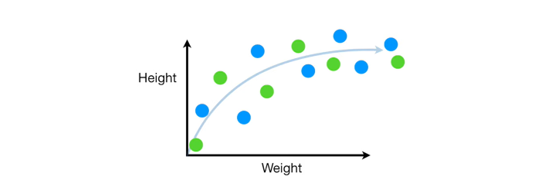

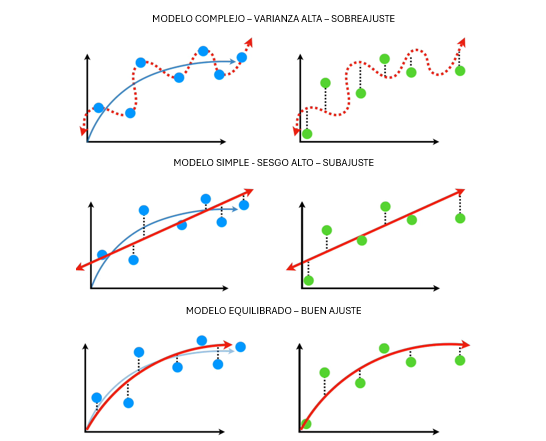

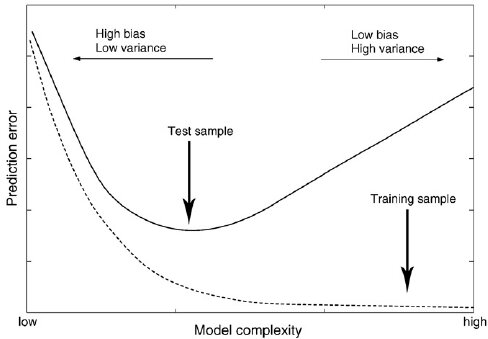

# Ensambles

Un ensamble es una técnica que **combina las predicciones de múltiples modelos individuales** (modelos base) para obtener una mejor predicción final en términos de precisión y robustez.

## Voting

Voting combina las predicciones de varios modelos obtenidos con distintos algoritmos (árboles, KNN, regresión lineal, etc.) mediante un voto mayoritario (para clasificación) o un promedio (para regresión). Existen dos tipos de voting:

- **Hard Voting:** Voto mayoritario. Cada modelo emite un voto por una clase, y la clase con más votos es la predicción final.

- **Soft Voting:** Promedia las probabilidades de predicción y elige la clase con la probabilidad promedio más alta.

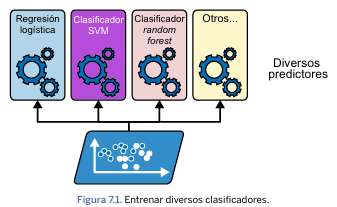

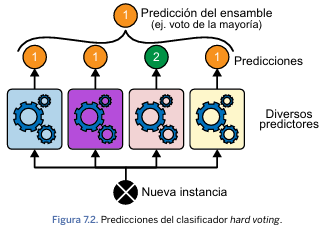

## Bagging (Bootstrap Aggregating)

Otro enfoque es utilizar el mismo algoritmo de entrenamiento para cada predictor y entrenarlos en diferentes subconjuntos aleatorios del conjunto de entrenamiento.

Bagging controla el overfitting mediante la creación de múltiples subconjuntos de los datos de entrenamiento con reposición (bootstrap samples). Cada subconjunto se utiliza para entrenar un modelo independiente, y las predicciones finales se obtienen mediante el promedio (para regresión) o el voto mayoritario (para clasificación).


Como proporcionan una manera de reducir el sobreajuste, los métodos de bagging funcionan mejor con modelos complejos (llamado *strong learners*, por ejemplo, árboles de decisión completamente desarrollados), en contraste con los métodos de boosting que generalmente funcionan mejor con modelos más simples (llamados *weak learners*, por ejemplo, árboles de decisión poco profundos).



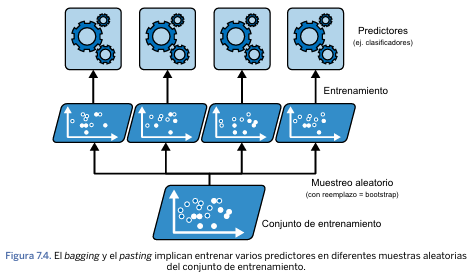

### Random forest

Un random forest es un ensamble
de árboles de decisión, entrenado mediante el método bagging.
El algoritmo random forest introduce una aleatoriedad extra cuando hace crecer los árboles; en vez de buscar el mejor atributo cuando divide un nodo, busca el mejor atributo entre un subconjunto aleatorio de características. Por defecto, muestrea $\sqrt{n}$ atributos (donde n es el número total de atributos). El algoritmo tiene como resultado una diversidad de árboles mayor, lo cual (de nuevo) compensa un sesgo más alto por una varianza más baja, produciendo habitualmente, un modelo mejor a nivel general.


Otra ventaja de los random forests es que permiten medir la **importancia relativa de cada atributo**. Scikit-Learn mide la importancia de una atributo
fijándose en cuánto reducen la impureza, en promedio, los nodos de árboles que utilizan ese atributo, a través de todos los árboles del bosque. En particular, se utiliza una media ponderada, donde el peso de cada nodo es igual al número de muestras de entrenamiento que están asociadas a él. Scikit-Learn computa esta puntuación de manera automática para cada atributo después del entrenamiento y, después, escala los
resultados de manera que la suma de todas las importancias sea igual a 1.

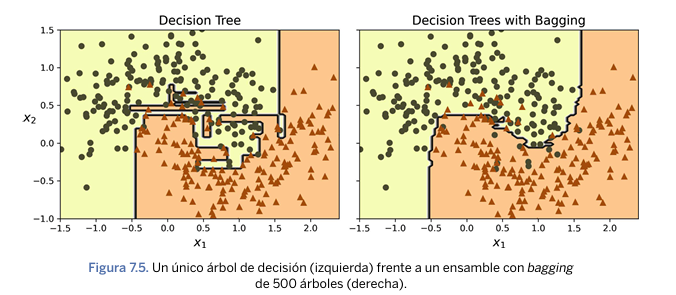

#### Ejemplo RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo de Random Forest
rf_model = RandomForestClassifier(n_estimators=30, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el reporte de clasificación
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Mostrar la matriz de confusión
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


## Boosting
Boosting incrementa la capacidad predictiva del modelo al entrenar secuencialmente múltiples modelos, donde cada modelo intenta corregir los errores de su predecesor.

Esta técnica de aprendizaje secuencial tiene un inconveniente importante: el
entrenamiento no puede usarse en paralelo, puesto que cada predictor solo puede entrenarse
después de que el predictor anterior se haya entrenado y evaluado. Como resultado, no escala
tan bien como el bagging.

### AdaBoost

El principio básico de AdaBoost es ajustar una secuencia de *weak learners* en versiones del conjunto de datos modificadas repetidamente.
Como mencionamos anteriormente los *weak learners* son modelos que son apenas mejor que una predicción aleatoria, como pueden ser árboles de baja profundidad.

Las predicciones de todos esos modelos después se combinan mediante la mayoría ponderada de votos para realizar la predicción final. Cuanto más exacto sea el predictor, más alto será su peso.


Las modificaciones que se realizan en los datos en cada itereación de boosting, consisten en aplicar pesos a cada una de las muestras del conjunto de entrenamiento. Inicialmente, todo los pesos se setean en 1/N, por lo que en el primer paso simplemente se entrena un *weak learner* con los datos originales. Para cada iteración sucesiva, los pesos de las muestras se modifican individualmente y el algoritmo de aprendizaje se vuelve a aplicar a los datos reponderados. Se aumentan los pesos de las muestras que fueron predichas incorrectamente en los pasos anteriores, mientras que se reducen los pesos de las que fueron predichas correctamente. A medida que avanzan las iteraciones, las instancias difíciles de predecir ganan mayor influencia. Los siguientes predictores se ven entonces forzados a concentrarse en esas instancias.

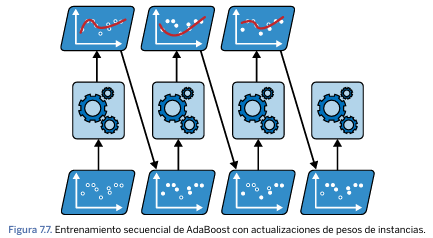

#### Ejemplo AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Crear el modelo de AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo
ada_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = ada_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el reporte de clasificación
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Mostrar la matriz de confusión
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  1  7]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definir el modelo base con DecisionTreeClassifier y AdaBoostClassifier
base_tree = DecisionTreeClassifier(random_state=42)
ada_model = AdaBoostClassifier(estimator=base_tree, random_state=42)

# Definir los hiperparámetros a optimizar, incluidos los del modelo base
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2, 3, 4, 5]  # Hiperparámetro del árbol de decisión
}

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=ada_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Ajustar el modelo a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Usar el mejor modelo encontrado para hacer predicciones
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluar el rendimiento del mejor modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Mostrar el reporte de clasificación
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Mostrar la matriz de confusión
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Mejores hiperparámetros: {'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 100}
Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  1  7]]


## Stacking

Se basa en una idea sencilla: en vez de utilizar funciones triviales (como el *hard voting*) para agregar
las predicciones de todos los predictores en un ensamble, se entrenamos un modelo para que lleve a cabo esa agregación.

Stacking combina múltiples modelos (denominados de nivel base) mediante un modelo meta-aprendizaje (meta-modelo). Las predicciones de los modelos de nivel base se utilizan como *features* de entrada para el meta-modelo, que aprende a realizar la predicción final.

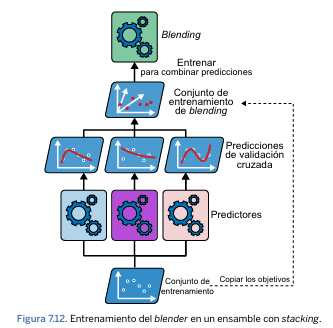

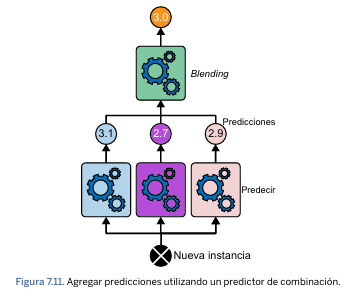

# Bibliografía

- Géron, A. (2020). Aprende machine learning con scikit-learn, keras y tensorflow. España: Anaya.
- Szretter Noste, M. E. (2013). Apunte de regresión lineal. Buenos Aires. Disponible en [este link](https://mate.dm.uba.ar/~meszre/apunte_regresion_lineal_szretter.pdf).
- Trade-off sesgo-varianza: [StatQuest - Fundamentos del aprendizaje automático: sesgo y varianza](https://www.youtube.com/watch?v=EuBBz3bI-aA)

